# Variante `montage_leadfield` — Universal EEG Transformer


El **Universal EEG Transformer** en modo **montaje** unifica grabaciones con
**cualquier configuración de electrodos** hacia un espacio canónico y,
desde ahí, hacia las cuatro referencias de EEG:
`unipolar`, `bipolar`, `CAR` y `REST` (todas de `C = 64` canales).

### Idea: proyectar y refinar

1. Un montaje de `C_s` electrodos (p. ej. 10-20, `C_s = 19`) observa la
   actividad del cuero cabelludo solo en sus posiciones. La grabación real de
   esos electrodos se **simula** de forma fiel: se parte de la referencia al
   infinito (REST) del montaje completo y se observan sus columnas en los
   electrodos del montaje fuente; sobre esa observación se computan las 4
   referencias **del propio montaje** (sus operadores, con su lead field).

2. Una matriz de proyección **fija** `P (C_s × C)` lleva la observación al
   espacio canónico: `x ∈ R^{C_s} ↦ x·P ∈ R^C`.

3. El **autoencoder lineal universal** aprende a refinar la proyección y a
   estimar las 4 referencias canónicas desde `x·P`: la conversión
   `s→d` queda como la matriz `A_{s→d} = P·W^{enc}_s·W^{dec}_d` (C_s×C).

### Los dos mecanismos de proyección (`mapping.method`)

| Método | Variante | Mecanismo | Suavizado |
|---|---|---|---|
| `leadfield` | `montage_leadfield` | **Solución inversa**: estima los potenciales canónicos resolviendo `P = W_s (W_s G_s)^{+T} G_c^T` con el lead field analítico multicapa | SVD truncado a `C_s//3` (el problema está mal condicionado, cond ~1e15) |
| `spline` | `montage_heatmap` | **Heatmap/topomapa**: interpolación esférica (Perrin) de la actividad entre los electrodos, que se percibe como **manchas** sobre el cuero cabelludo | Ridge que crece con la `densidad`: a montajes más dispersos, más suavizado |

### Calidad de la proyección pura (sin aprendizaje)

Reconstrucción *round-trip* al canónico con **solo** la proyección
(`data/mapping_results.csv`, test, 12 sujetos):

| Montaje | leadfield (ve) | spline (ve) | nearest (ve) |
|---|---|---|---|
| 10-20 (19) | **0.273** | 0.104 | 0.099 |
| 10-10 (39) | **0.259** | 0.118 | 0.526 |

El modelo universal parte de esta línea base y aprende a superarla.

### Identidad de la variante

**`montage_leadfield`** — estimación por SOLUCIÓN INVERSA con el lead field analítico (config `config/montage_leadfield.yaml`).


La variante **`montage_leadfield`** proyecta las observaciones del montaje
fuente con el operador de **solución inversa**

```
P = W_s (W_s G_s)^{+T} G_c^T ,      W_s = I − 11ᵀ/C_s
```

que estima los potenciales al infinito en las posiciones canónicas a partir de
los electrodos fuente (equivalente a REST pero entre montajes).

Como el problema inverso `W_s G_s` está fuertemente mal condicionado
(cond ≈ 1e15), los mínimos cuadrados sin regularizar amplifican el ruido real
(`ve` negativa). Se **trunca el SVD** a `n_components ≈ C_s//3` (modos
espaciales de baja frecuencia), lo que estabiliza la proyección (ve ≈ 0.27 en
10-20) y deja al autoencoder refinar el resto.

**Resultado esperado**: el modelo aprende a corregir la estimación inversa y
a componer las 4 referencias canónicas mejor que la proyección pura (la
columna `*_proy` de la tabla de evaluación es ese punto de partida).

**Resultado obtenido** (12 sujetos, test): el modelo supera la inversa pura —
RMSE cross ≈ **18.7 µV**, `r ≈ 0.623`, `ve ≈ 0.44` frente a ve ≈ 0.18 de la
proyección analítica. El desglose por ruta se muestra en la sección 4.


### Metodología del experimento

1. **Dataset real** `eegbci` (PhysioNet), sujetos 1–12, corridas 1–2:
   228 269 muestras × 64 canales, filtrado bandpass 1–45 Hz, split por
   bloques (train/val/test). El montaje 10-20 es un subconjunto exacto de los
   64 canales.
2. **Proyección fija** `P` construida con `mapping.build_projection`
   (`leadfield` con truncado SVD automático `C_s//3`, `spline` con
   `smoothness = 1e-5 · C_c/C_s`).
3. **Inicialización lineal empírica**: `init_from_data` ajusta las matrices
   sobre las observaciones **proyectadas** (`x·P`), de modo que el latente
   (`C=64`) ancla al unipolar canónico y cada ruta arranca bien condicionada.
4. **Pérdida**: MSE estandarizado (Z-score por lote) sobre las 16 rutas
   (origen del montaje fuente → destino canónico).
5. **Evaluación (test)**: RMSE/correlación por ruta de las estimaciones del
   modelo contra las referencias canónicas verdaderas, comparadas con la
   **proyección analítica pura** `obs @ P` (columnas `*_proy`).
6. **Figuras**: curvas de aprendizaje, heatmap de RMSE por ruta y **mapas de
   calor del cuero cabelludo** (electrodos → manchas) en 4 etapas:
   observación → proyección analítica → modelo → verdad canónica.


> **Nota de reproducción:** el modelo ya entrenado (12 sujetos) está en `runs/montage_leadfield`. Con `FORCE = False` el notebook **reutiliza el checkpoint** sin reentrenar (segundos); póngalo en `True` solo para reentrenar desde cero.

## 1. Carga del experimento

Configuración YAML, dataset real cacheado y los **insumos de montaje** (observaciones del montaje fuente + proyección `P`).

In [1]:
# ---- Configuración del entorno ----------------------------------------
# Renderizado inline de figuras (debe activarse antes de importar matplotlib)
%matplotlib inline

import os, sys
from pathlib import Path

# Ruta raíz del repo y paquetes propios (src/)
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# Las rutas relativas (data/, runs/, config/) se resuelven contra la raíz,
# no contra el cwd del kernel (correcto incluso desde otro directorio).
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from eeg_transform.nb import (
    config_table, evaluate_montage, load_experiment, montage_inputs,
    plot_routes, plot_scalp, plot_training, train_variant,
)
from eeg_transform.training.trainer import build_model

# Modo notebook: semillas fijas
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)
plt.rcParams["figure.dpi"] = 110

CONFIG = ROOT / "config/montage_leadfield.yaml"
FORCE  = False          # True = reentrenar desde cero ignorando el checkpoint

I0000 00:00:1787089350.302063   58557 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787089350.302391   58557 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787089350.340151   58557 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787089351.313160   58557 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787089351.313400   58557 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
cfg, ds = load_experiment(CONFIG)
mi = montage_inputs(cfg, ds)
print(ds.summary())
print(f"Montaje fuente: {mi.montage} ({len(mi.src_names)} electrodos) "
      f"via '{mi.method}' → canónico {ds.n_channels} canales")
config_table(cfg).set_index(["sección", "parámetro"])

Dataset: 228269 muestras x 64 canales
  lead field: 2006 fuentes (grid 10.0 mm)
  splits: train=146088, val=36524, test=45657
  sujetos: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Montaje fuente: 10-20 (19 electrodos) via 'leadfield' → canónico 64 canales


valor
sección   parámetro                                                       
data      subjects                 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
          runs                                                      [1, 2]
          bandpass                                             [1.0, 45.0]
          notch                                                         []
          unipolar_ref_ch                                               Cz
          original_reference                                  left_mastoid
          artifact_z_thresh                                            6.0
          artifact_min_max_volts                                    0.0005
          bad_channel_z_thresh                                         4.0
          n_jobs                                                         1
leadfield head_radius                                                 0.09
          rel_radii                                 [0.87, 0.9, 0.97, 1.0]
          sigmas                                 [0.33, 1.0, 0.0042, 0.33]
          brain_radius                                               0.078
          src_grid_mm                                                 10.0
          drop_bad_sources                                            True
dataset   cache_dir                                         data/processed
          split_mode                                                 block
          test_frac                                                    0.2
          val_frac                                                     0.2
          seed                                                          42
          max_samples_per_subject                                    60000
          dtype                                                    float32
model     latent_dim                                                     0
          use_bias                                                   False
          kernel_regularizer_l2                                   0.000001
          optimizer                                                   adam
          learning_rate                                              0.001
          variant                                        montage_leadfield
          comp_penalty_weight                                          0.0
training  epochs                                                        60
          batch_size                                                  1024
          early_stop_patience                                           10
          reduce_lr_patience                                             5
          reduce_lr_factor                                             0.5
          min_lr                                                   0.00001
          shuffle_buffer                                             20000
          prefetch                                                       4
          run_dir                                   runs/montage_leadfield
          log_file                        runs/montage_leadfield/train.log
          save_best_only                                              True
          seed                                                          42

## 2. Arquitectura

Autoencoder universal + **proyección fija** `P (C_s→C)`: la ruta efectiva `s→d` es `A = P·W_enc·W_dec` y opera sobre las observaciones del montaje fuente.

In [3]:
# Arquitectura efectiva: autoencoder universal + proyección fija P
model = build_model(cfg, ds.n_channels, projection=mi.projection)
model.ensure_built()

n_params = sum(int(np.prod(v.shape)) for v in model.trainable_variables)
print(f"Variante: {cfg.model.variant}  |  latente: {cfg.model.latent_dim}  |  "
      f"montaje origen: {len(mi.src_names)} → canónico: {ds.n_channels}  |  "
      f"parámetros entrenables: {n_params:,}")
print(f"Proyección P: {mi.projection.shape} "
      "(fija; el autoencoder refina y convierte de referencias)")
print(f"Ruta efectiva s→d: A = P · W_enc_s · W_dec_d")
_ = model  # se reutiliza en train/eval

Variante: montage_leadfield  |  latente: 64  |  montaje origen: 19 → canónico: 64  |  parámetros entrenables: 32,768
Proyección P: (19, 64) (fija; el autoencoder refina y convierte de referencias)
Ruta efectiva s→d: A = P · W_enc_s · W_dec_d


E0000 00:00:1787089352.965042   58557 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 3. Entrenamiento

Igual que las variantes canónicas (Adam, Z-score por lote, early stopping) pero sobre observaciones de montaje. Reutiliza el checkpoint si existe.

In [4]:
# Entrenamiento (reutiliza best.weights.h5 si existe, salvo FORCE=True)
model, history = train_variant(cfg, ds, force=FORCE)
run_dir = Path(cfg.training.run_dir)
print(f"run_dir: {run_dir}")

run_dir: runs/montage_leadfield


## 4. Evaluación en test

Métricas del **modelo** vs la **proyección analítica pura** (`obs @ P`, columnas `*_proy`): la ganancia cuantifica el refinamiento que aprende el transformador.

In [5]:
# Evaluación en test: RMSE/ve por ruta vs proyección analítica pura (P)
metrics_df, summary = evaluate_montage(cfg, ds, model, montage=mi)

print("=== RESUMEN MONTAJE (RMSE en µV): modelo vs proyección analítica ===")
print(summary.round(3).to_string(index=False))
print("\n=== DETALLE POR RUTA (test) — columnas *_proy = solo proyección P ===")
print(metrics_df.round(9).to_string(index=False))

=== RESUMEN MONTAJE (RMSE en µV): modelo vs proyección analítica ===
                          tipo  rmse_uV_model  r_model  ve_model  rmse_uV_proy  r_proy  ve_proy
auto-reconstrucción (diagonal)         18.554    0.629     0.450        21.159   0.555    0.273
        transformación cruzada         18.704    0.623     0.442        22.474   0.507    0.181

=== DETALLE POR RUTA (test) — columnas *_proy = solo proyección P ===
  origen  destino          mse     rmse      mae        r       ve  rmse_proy   r_proy   ve_proy
unipolar unipolar 0.000000e+00 0.000017 0.000010 0.707119 0.511680   0.000019 0.683575  0.430788
unipolar  bipolar 1.000000e-09 0.000023 0.000012 0.403497 0.266718   0.000029 0.142223 -0.214973
unipolar      car 0.000000e+00 0.000017 0.000010 0.707136 0.511712   0.000019 0.683575  0.430788
unipolar     rest 0.000000e+00 0.000017 0.000010 0.706529 0.510953   0.000019 0.683575  0.430788
 bipolar unipolar 0.000000e+00 0.000018 0.000010 0.676568 0.476801   0.000024 0.518293 

## 5. Figuras inline

Curvas de aprendizaje, heatmap de RMSE por ruta (modelo) y los **mapas de calor del cuero cabelludo** que muestran la actividad como manchas desde el montaje fuente hasta la verdad canónica.

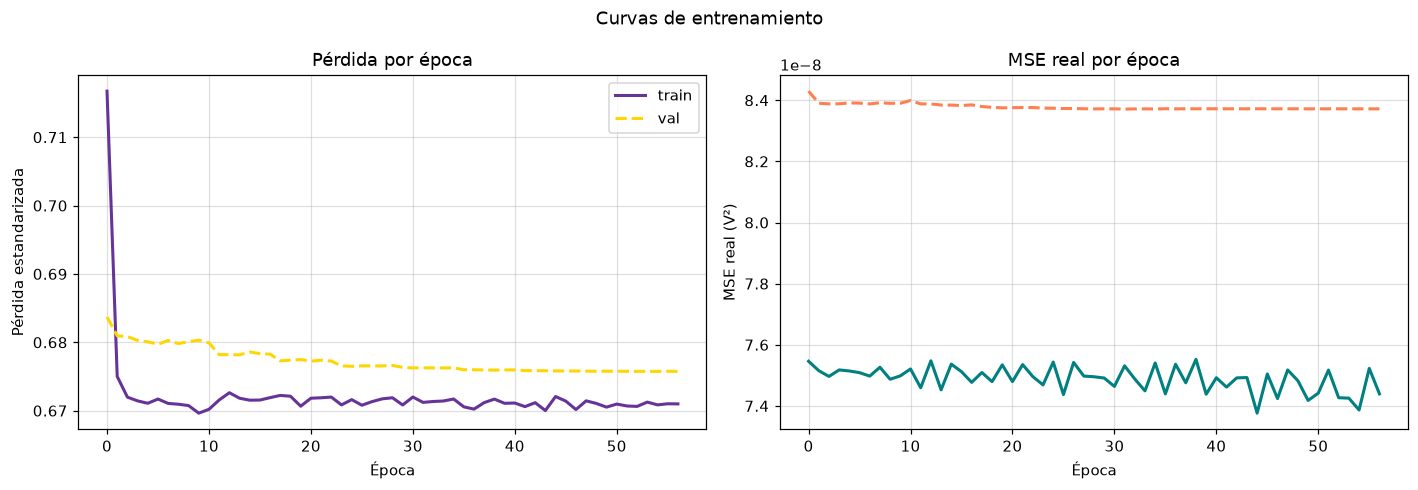

In [6]:
# Curvas de aprendizaje (pérdida estandarizada y MSE real)
plot_training(run_dir / "history.csv")
plt.show()

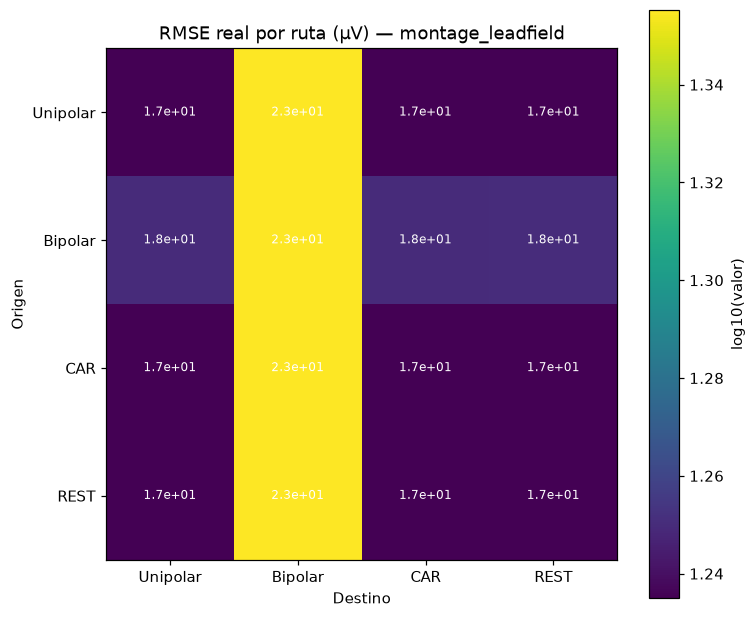

In [7]:
# Heatmap de RMSE real por ruta origen→destino (µV, escala log10)
plot_routes(metrics_df, value_col="rmse",
            title=f"RMSE real por ruta (µV) — {cfg.model.variant}")
plt.show()

/home/aess/Proyectos/universal-eeg-transformer/src/eeg_transform/evaluation/plots.py:238: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.97))


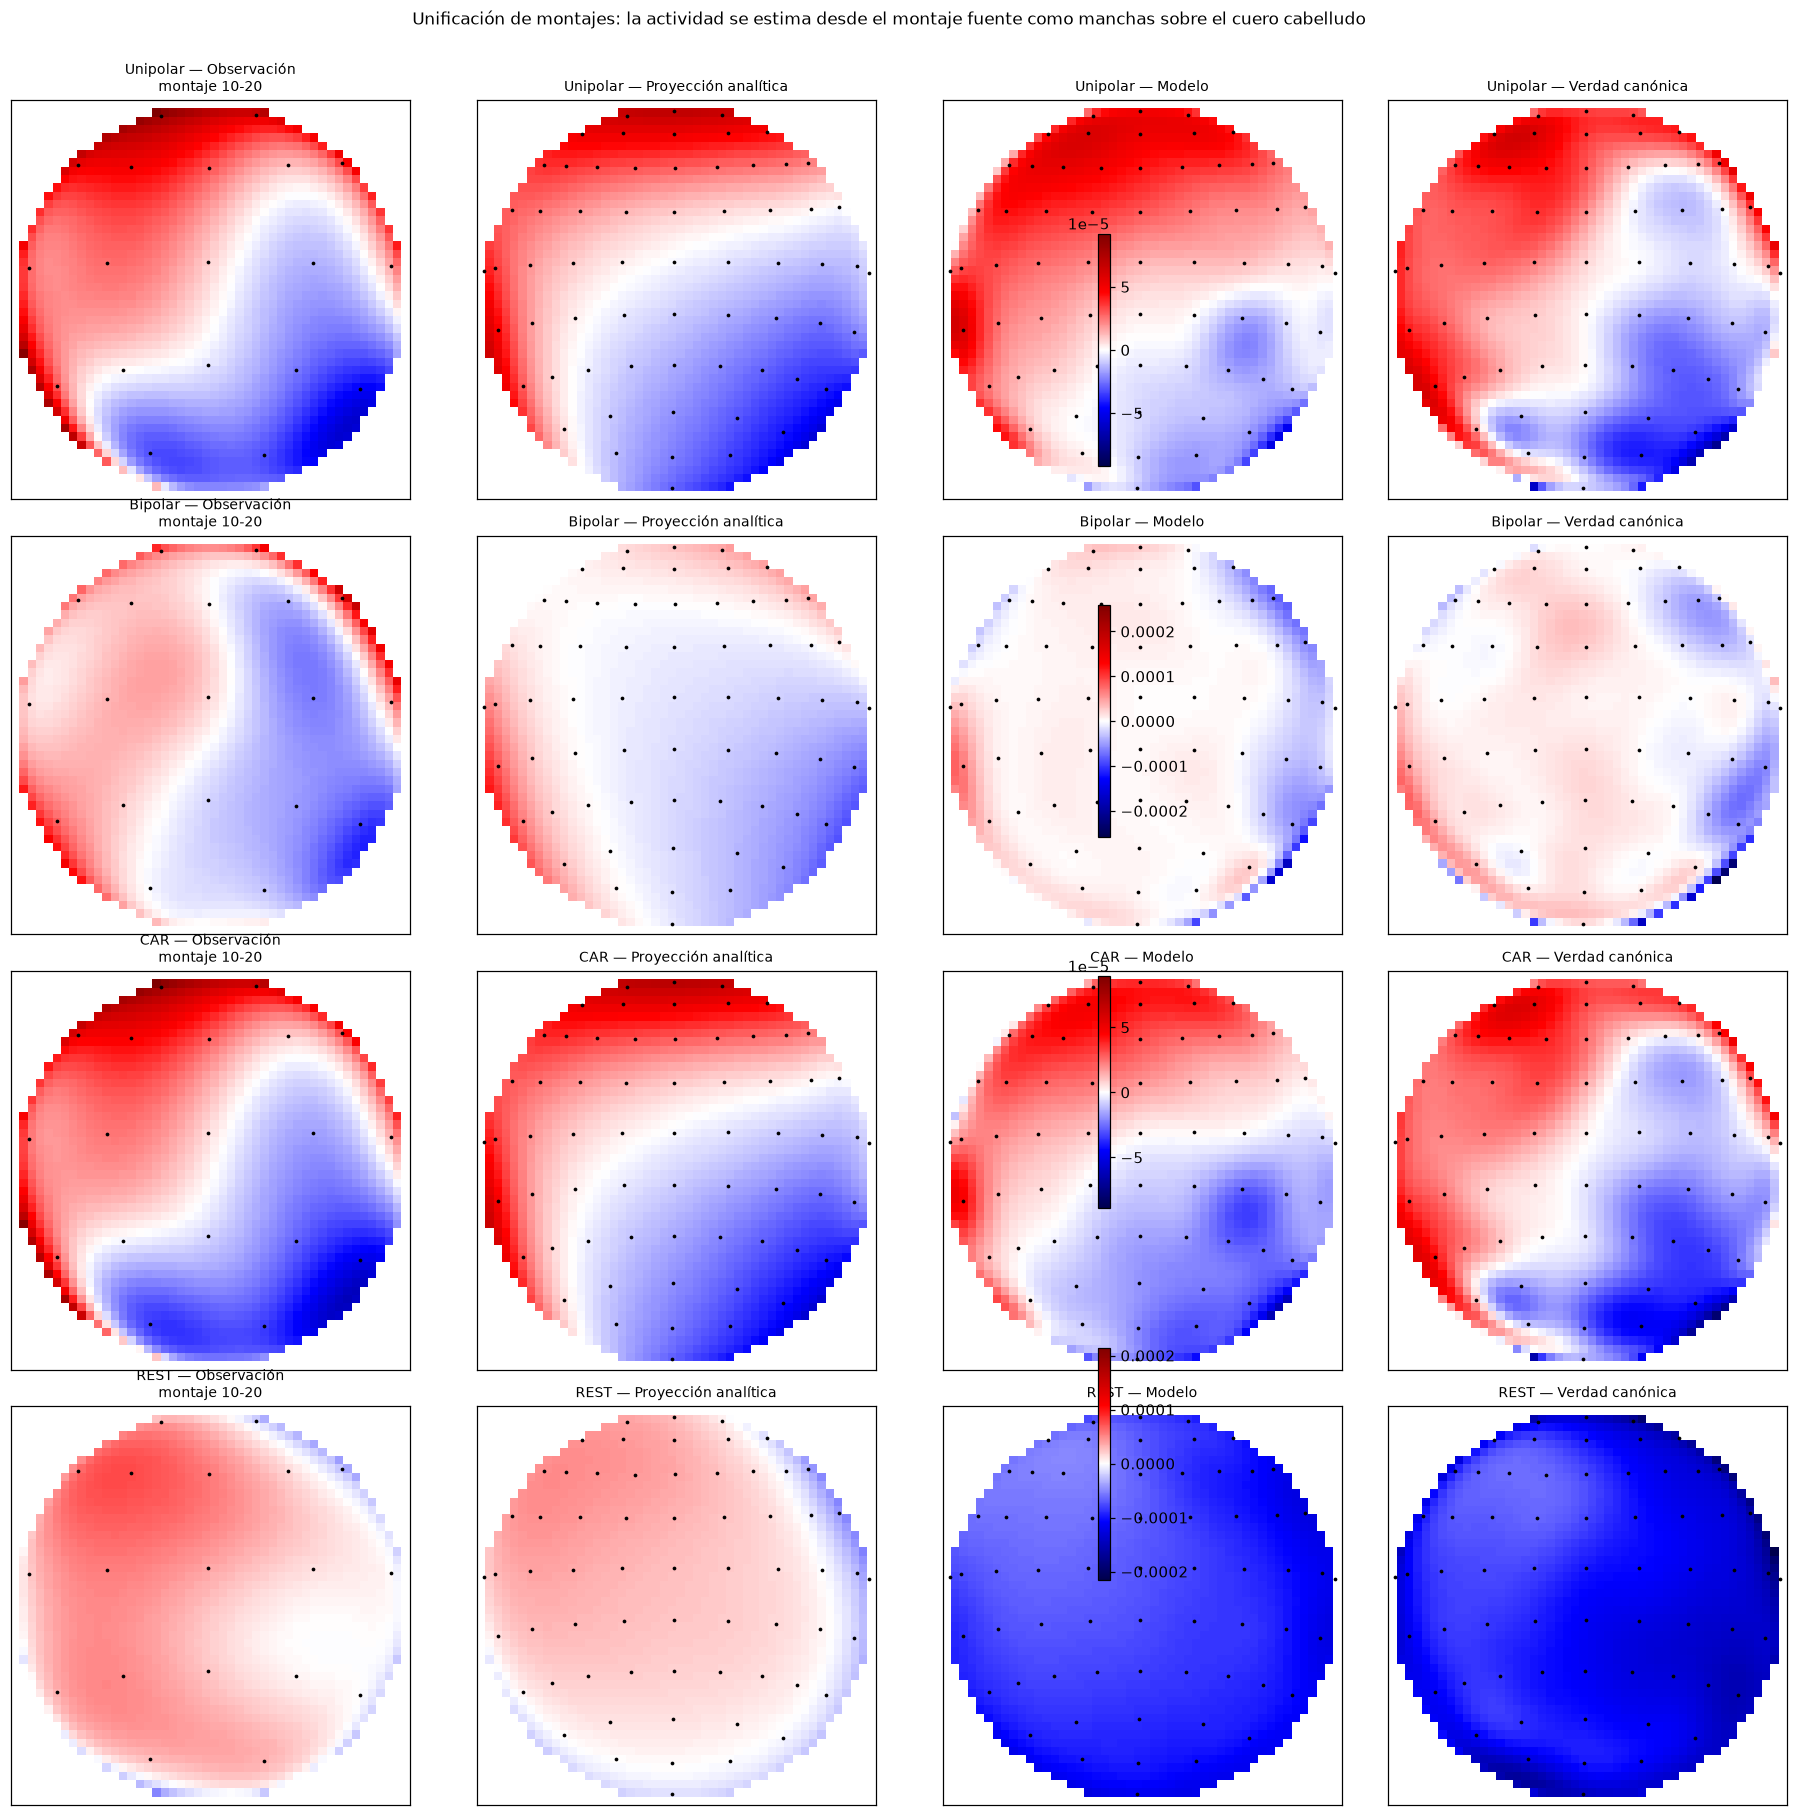

In [8]:
# Mapas de calor del cuero cabelludo: electrodos como manchas de actividad
# Filas = referencia; columnas: observación del montaje fuente → proyección
# analítica → modelo → verdad canónica (el instante de máxima amplitud).
plot_scalp(cfg, ds, model, montage=mi)
plt.show()

## Conclusiones

Consulte `docs/mapping_wip.md` y `docs/results_comparison.md` para la interpretación comparativa de la unificación de montajes frente a las variantes canónicas.